In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
spam1 = pd.read_csv('spam.csv',encoding='latin-1')
spam2 = pd.read_csv('emails.txt',encoding='latin-1', sep=',', engine='python',on_bad_lines='warn',header=None)

In [3]:
spam2.rename(columns={0:'label',1:'text'},inplace=True)

In [4]:
spam1 = spam1[['v1','v2']].rename(columns={'v1':'label','v2':'text'})

In [5]:
print(spam1.shape)
print(spam2.shape)

(5572, 2)
(1376, 2)


In [6]:
emails = pd.concat([spam1,spam2])

In [7]:
emails.duplicated().sum()

np.int64(418)

In [8]:
emails.drop_duplicates(inplace=True)

In [9]:
df = emails.copy()

In [10]:
df.head(3)

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [11]:
# encode the label column
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [12]:
df.head(3)

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


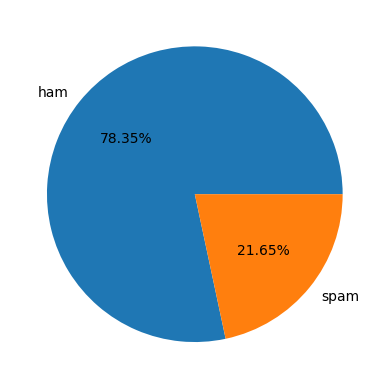

<Figure size 400x400 with 0 Axes>

In [15]:
plt.pie(df['label'].value_counts(),labels = ['ham','spam'],autopct="%0.2f%%")
plt.figure(figsize=(4,4))
plt.show()

In [16]:
import nltk
nltk.download('punkt_tab')
text = "Hello there! Mr. Wayne is home. Is it 5:00 p.m. yet?"
sentences = nltk.sent_tokenize(text)
words = nltk.word_tokenize(text)

print(sentences)
print(words)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Hello there!', 'Mr. Wayne is home.', 'Is it 5:00 p.m. yet?']
['Hello', 'there', '!', 'Mr.', 'Wayne', 'is', 'home', '.', 'Is', 'it', '5:00', 'p.m.', 'yet', '?']


In [17]:
df['num_chars'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sents'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head(2)

,label,text,num_chars,num_words,num_sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2


In [18]:
df[df['label'] == 0][['num_chars','num_words','num_sents']].describe()

,num_chars,num_words,num_sents
count,5116.000000,5116.000000,5116.000000
mean,72.949765,17.344996,1.774238
std,53.819502,12.759081,1.317322
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,14.000000,1.000000
75%,96.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
df[df['label'] == 1][['num_chars','num_words','num_sents']].describe()

,num_chars,num_words,num_sents
count,1414.000000,1414.000000,1414.000000
mean,115.228430,23.639321,2.606082
std,32.655412,6.815434,1.148428
min,13.000000,2.000000,1.000000
25%,89.000000,18.000000,2.000000
50%,112.500000,23.000000,2.000000
75%,147.000000,29.000000,3.000000
max,224.000000,46.000000,9.000000


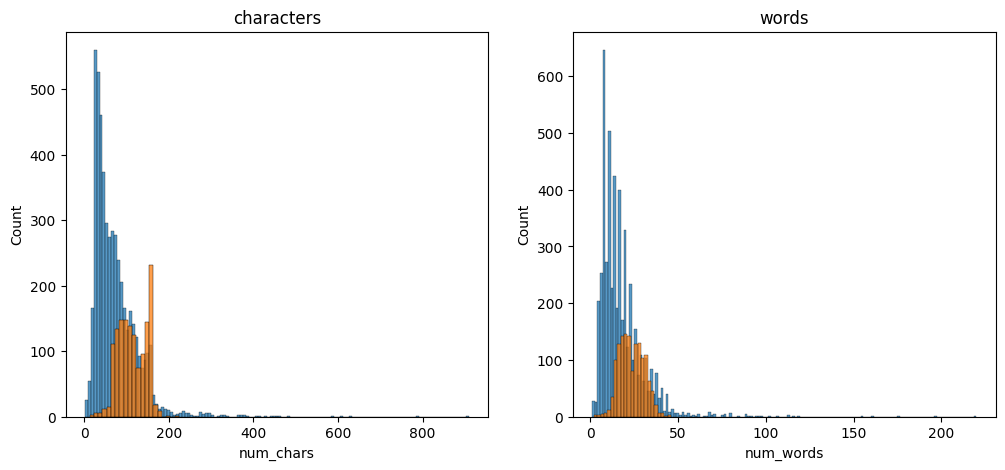

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[df['label'] == 0]['num_chars'])
sns.histplot(df[df['label'] == 1]['num_chars'])
plt.title("characters")

plt.subplot(1,2,2)
sns.histplot(df[df['label'] == 0]['num_words'])
sns.histplot(df[df['label'] == 1]['num_words'])
plt.title("words")

plt.show()

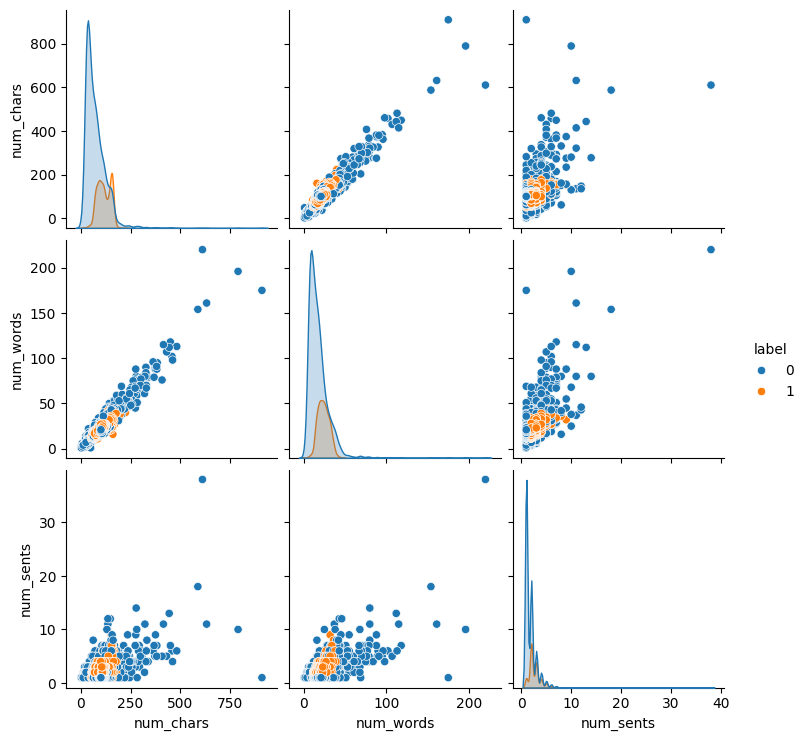

In [30]:
sns.pairplot(df,hue='label')

<Axes: >

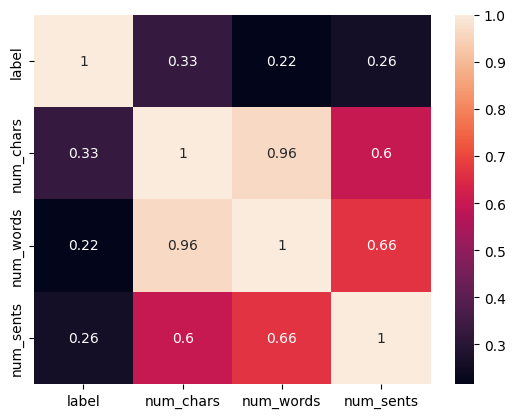

In [31]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

- data has multicollinearity means features strongly dependent on each other
- so we have remove some features and select that features which is strongly related to target
    - in above case it is `no_characters`

# data preprocessing

In [32]:
df1 = df.copy()

In [33]:
df['text'] = df['text'].str.lower()

In [34]:
import string
exclude = string.punctuation
def remove_punc(text):
  table = str.maketrans('','',exclude)
  return text.translate(table)
remove_punc("freemsg hey there darling it's been 3 week's now and no word back!")

'freemsg hey there darling its been 3 weeks now and no word back'

In [35]:
# from nltk.chunk.named_entity import word_tokenize
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
def remove_stopwords(text):
  words = []
  for word in nltk.word_tokenize(text):
    if not word in stop_words:
      words.append(word)
  return " ".join(words)

remove_stopwords("nah i dont think he goes to usf he lives around here though")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


'nah dont think goes usf lives around though'

In [36]:
# stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def stem_words(text):
  words = []
  for word in nltk.word_tokenize(text):
    words.append(ps.stem(word))
  return " ".join(words)
stem_words("nah i dont think he goes to usf he lives around here though")

'nah i dont think he goe to usf he live around here though'

In [37]:
df['text'] = df['text'].apply(remove_punc)
df['text'] = df['text'].apply(remove_stopwords)
df['text'] = df['text'].apply(stem_words)

In [38]:
# spelling correction
# incorrect_text = "freemsg hey there darling its been 3 weeks now and no word back id like some fun you up for it still tb ok xxx std chgs to send å£150 to rcv"
# from textblob import TextBlob
# tb = TextBlob(incorrect_text)
# print(tb.correct().string)

In [39]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

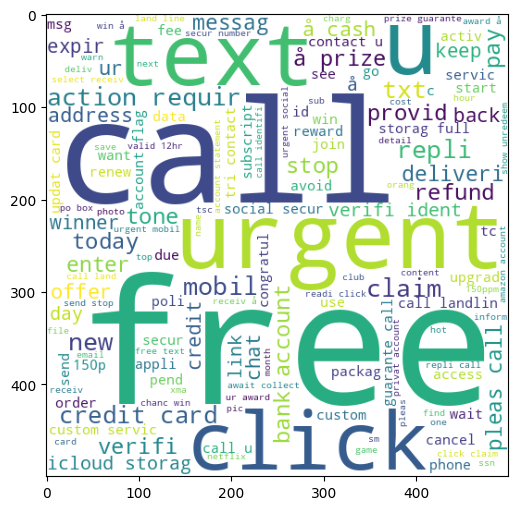

In [40]:
spam_wc = wc.generate(df[df['label'] == 1]['text'].str.cat(sep = " "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

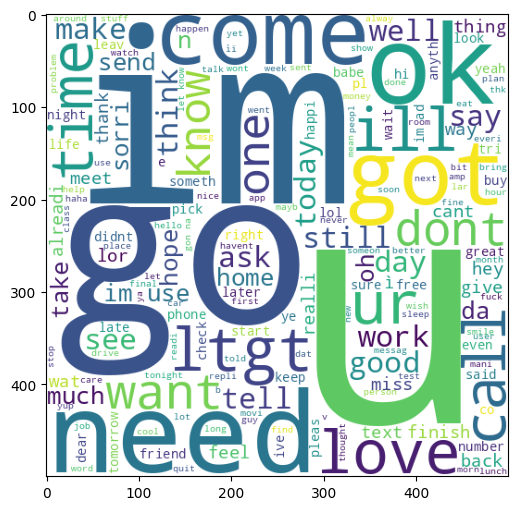

In [41]:
ham_wc = wc.generate(df[df['label'] == 0]['text'].str.cat(sep = " "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [42]:
spam_corpus = []
for msg in df[df['label'] == 1]['text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
len(spam_corpus)

18063

In [43]:
ham_corpus = []
for msg in df[df['label'] == 0]['text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)

42728

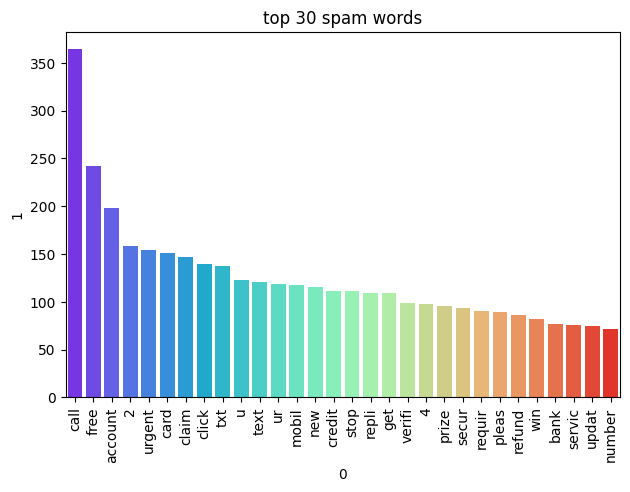

In [44]:
from collections import Counter
temp_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x = temp_spam[0],y=temp_spam[1],palette='rainbow')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.title('top 30 spam words')
plt.show()

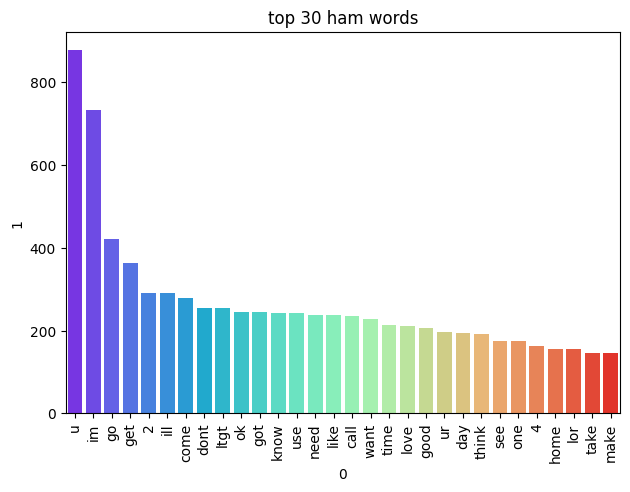

In [45]:
temp_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x = temp_ham[0],y= temp_ham[1],palette='rainbow')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.title('top 30 ham words')
plt.show()

# Model Building

In [46]:
y= df['label'].values
X= df['text']

In [47]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=5000)

tfidf.fit(X_train)
X_train = tfidf.transform(X_train)
X_test = tfidf.transform(X_test)

In [50]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [51]:
mnb.fit(X_train,y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9663093415007658
[[1024    2]
 [  42  238]]
0.9916666666666667


In [52]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9816232771822359
[[1024    2]
 [  22  258]]
0.9923076923076923


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [54]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
bnb = BernoulliNB()
lrc = LogisticRegression(solver='liblinear',penalty='l1')
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)

In [55]:
clfs = {
    'SVC':svc, 'KN':knc, 'MNB':mnb, 'LR':lrc, 'RF':rfc, 'ETC':etc, 'BNB':bnb
}

In [56]:
def train_classifier(clf,X_train,X_test,y_train,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    return accuracy_score(y_test,y_pred), precision_score(y_test,y_pred)

In [57]:
train_classifier(mnb,X_train,X_test,y_train,y_test)

(0.9663093415007658, 0.9916666666666667)

In [58]:
accuracy_scores = []
precision_scores = []
algo = []
for name,clf in clfs.items():
    curr_accuracy, curr_precision = train_classifier(clf,X_train,X_test,y_train,y_test)
    algo.append(name)
    accuracy_scores.append(curr_accuracy)
    precision_scores.append(curr_precision)

In [59]:
performance_df = pd.DataFrame({
    'Algorithm':algo,'Accuracy':accuracy_scores, 'Precision':precision_scores
}).sort_values('Precision',ascending=False)

In [60]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.852986,1.000000
6,BNB,0.981623,0.992308
2,MNB,0.966309,0.991667
0,SVC,0.982389,0.977695
4,RF,0.972435,0.962121
5,ETC,0.974732,0.955720
3,LR,0.954824,0.947368


In [61]:
# voting classifier
svc = SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb = MultinomialNB()
bnb = BernoulliNB()
rfc = RandomForestClassifier(n_estimators=50,random_state=2)

from sklearn.ensemble import VotingClassifier

In [62]:
voting = VotingClassifier(estimators=[('svm',svc),('mn',mnb),('rf',rfc),('bn',bnb)],voting='soft')
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('mn', MultinomialNB()),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2)),
                             ('bn', BernoulliNB())],
                 voting='soft')

In [63]:
y_pred = voting.predict(X_test)
print('Accuracy: ',accuracy_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))

Accuracy:  0.9839203675344563
Precision:  0.9923954372623575


In [64]:
def transform_text(text):
  text = str(text).lower()

  import string
  punctuations = string.punctuation
  table = str.maketrans('','',punctuations)
  text = text.translate(table)

  from nltk.corpus import stopwords
  stop_words = stopwords.words('english')
  words = []
  for word in nltk.word_tokenize(text):
    if not word in stop_words:
      words.append(word)
  text = " ".join(words)

  from nltk.stem.porter import PorterStemmer
  ps = PorterStemmer()
  words = []
  for word in nltk.word_tokenize(text):
    words.append(ps.stem(word))
  text = " ".join(words)

  return text

In [65]:
text = '''
  Your account has been compromised.
  Please click the link below to verify your identity within 24 hours or your account will be deleted.
'''
text_data = transform_text(text)
vectorized_text = tfidf.transform([text_data])
prediction = voting.predict(vectorized_text)
probabilities = voting.predict_proba(vectorized_text)
print(prediction[0], probabilities[0][1])

1 0.9668318436571298


In [110]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

def transform_text_pipeline(X):
    new_text = []

    for text in X:
        text = str(text).lower()
        table = str.maketrans('', '', string.punctuation)
        text = text.translate(table)

        stop_words = set(stopwords.words('english'))
        words = [word for word in nltk.word_tokenize(text) if word not in stop_words]

        ps = PorterStemmer()
        stemmed_words = [ps.stem(word) for word in words]

        new_text.append(" ".join(stemmed_words))

    return new_text

In [111]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
bnb = BernoulliNB()
rfc = RandomForestClassifier(n_estimators=50,random_state=2)

voting = VotingClassifier(estimators=[('svm', svc),('mn', mnb),('rf', rfc),('bn',bnb)],voting='soft')

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

pipe = Pipeline([
    ('preprocessor', FunctionTransformer(func=transform_text_pipeline)),
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', voting)
])


In [113]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df1['text'],y,test_size=0.2,random_state=2)

In [114]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 FunctionTransformer(func=<function transform_text_pipeline at 0x7cdf63f97100>)),
                ('vectorizer', TfidfVectorizer(max_features=5000)),
                ('classifier',
                 VotingClassifier(estimators=[('svm',
                                               SVC(gamma=1.0, kernel='sigmoid',
                                                   probability=True)),
                                              ('mn', MultinomialNB()),
                                              ('rf',
                                               RandomForestClassifier(n_estimators=50,
                                                                      random_state=2)),
                                              ('bn', BernoulliNB())],
                                  voting='soft'))])

In [118]:
text = '''
  Your account has been compromised.
  Please click the link below to verify your identity within 24 hours or your account will be deleted.
'''
prediction = pipe.predict([text])
probabilities = pipe.predict_proba([text])
print(prediction[0], probabilities[0][1])

1 0.9668318394145283


In [117]:
import pickle
with open('email_clf_pipe.pkl', 'wb') as f:
    pickle.dump(pipe, f)
